In [1]:
# %%
"""
📌 Notebook: 05_lstm_model.ipynb (HIGH ACCURACY VERSION)

🎯 Purpose:
Train an optimized LSTM model for driving behavior classification.

🔥 Improvements:
- Bidirectional LSTM (captures forward + backward patterns)
- Learning rate scheduler
- Class balancing
- Stronger architecture
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.utils.class_weight import compute_class_weight

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [2]:
# %%
# GPU Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU ready.")
    except RuntimeError as e:
        print(e)

✅ GPU ready.


In [3]:
# %%
# Safe folder creation
folders = ["../models", "../results/graphs", "../results/confusion_matrix"]

for folder in folders:
    if os.path.isfile(folder):
        os.remove(folder)
    os.makedirs(folder, exist_ok=True)

In [4]:
# %%
# Load data
X_train = np.load("../processed_data/X_train.npy")
y_train = np.load("../processed_data/y_train.npy")
X_test = np.load("../processed_data/X_test.npy")
y_test = np.load("../processed_data/y_test.npy")

# ✅ FIX LABELS (IMPORTANT)
y_train = y_train - 1
y_test = y_test - 1

print("✅ Data loaded.")
print(f"Shape: {X_train.shape}")

✅ Data loaded.
Shape: (109326, 100, 9)


In [5]:
# %%
"""
🔹 Compute Class Weights (IMPORTANT)
"""

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights)

✅ Class weights: {0: 1.1070987341772152, 1: 1.2029709507042254, 2: 0.8370415741520557, 3: 0.7594192831342039, 4: 1.3262889724614824}


In [6]:
# %%
"""
🔹 Model Architecture (Improved)
"""
model = models.Sequential([

    layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    # 🔥 Bidirectional LSTM (BIG BOOST)
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Bidirectional(layers.LSTM(64)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Dense layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    # Output layer
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 100, 256)         141312    
 l)                                                              
                                                                 
 batch_normalization (BatchN  (None, 100, 256)         1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 100, 256)          0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              164352    
 nal)                                                            
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                        

In [7]:
# %%
"""
🔹 Callbacks (VERY IMPORTANT)
"""

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "../models/best_lstm_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

# 🔥 Learning rate scheduler
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

In [8]:
# %%
"""
🔹 Training
"""

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights,   # 🔥 important
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

# Save history
with open('../results/lstm_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("✅ Training complete.")

Epoch 1/60
3075/3075 [==============================] - 261s 78ms/step - loss: 1.1335 - accuracy: 0.5078 - val_loss: 0.8559 - val_accuracy: 0.6533 - lr: 0.0010
Epoch 2/60
3075/3075 [==============================] - 215s 70ms/step - loss: 0.8777 - accuracy: 0.6333 - val_loss: 0.6963 - val_accuracy: 0.7246 - lr: 0.0010
Epoch 3/60
3075/3075 [==============================] - 216s 70ms/step - loss: 0.7381 - accuracy: 0.6942 - val_loss: 0.6678 - val_accuracy: 0.7376 - lr: 0.0010
Epoch 4/60
3075/3075 [==============================] - 214s 70ms/step - loss: 0.6652 - accuracy: 0.7263 - val_loss: 0.6031 - val_accuracy: 0.7557 - lr: 0.0010
Epoch 5/60
3075/3075 [==============================] - 214s 70ms/step - loss: 0.6191 - accuracy: 0.7452 - val_loss: 0.5170 - val_accuracy: 0.7920 - lr: 0.0010
Epoch 6/60
3075/3075 [==============================] - 214s 70ms/step - loss: 0.5760 - accuracy: 0.7644 - val_loss: 0.5364 - val_accuracy: 0.7774 - lr: 0.0010
Epoch 7/60
3075/3075 [==================

In [9]:
# %%
"""
💾 Save final model
"""
model.save("../models/lstm_model.h5")
print("✅ Model saved.")

✅ Model saved.


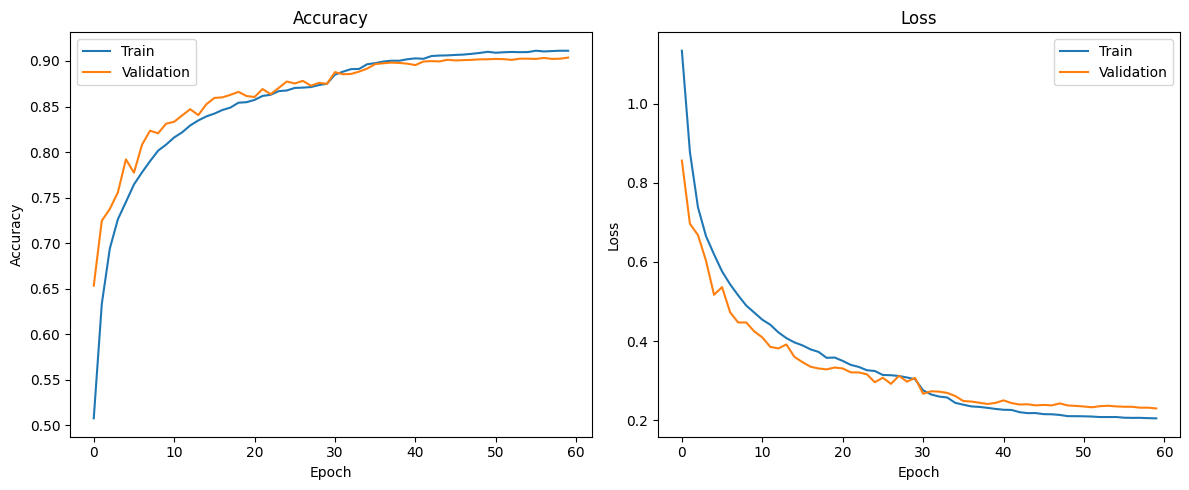

✅ Graph saved.


In [10]:
# %%
"""
📊 Plot Performance
"""

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../results/graphs/lstm_performance_curves.png')
plt.show()

print("✅ Graph saved.")